In [99]:
import pandas as pd
import seaborn as sns                 
import matplotlib.pyplot as plt                      


In [100]:
df=pd.read_csv(r"C:\Users\om420\Downloads\archive (7).zip",compression='zip',sep=', ')

df.head()

C:\Users\om420\AppData\Local\Temp\ipykernel_8652\4039962156.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df=pd.read_csv(r"C:\Users\om420\Downloads\archive (7).zip",compression='zip',sep=', ')


,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [101]:
print(df.columns.tolist())

['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']


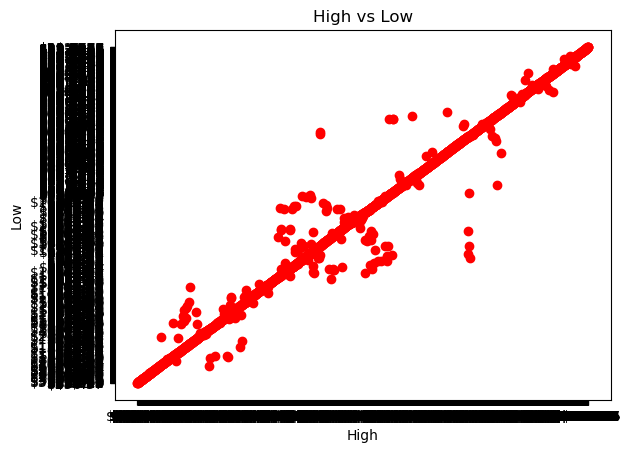

In [102]:
import matplotlib.pyplot as plt

plt.scatter(df['High'], df['Low'],color='red')
plt.xlabel('High')
plt.ylabel('Low')
plt.title('High vs Low')
plt.show()

In [104]:
df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)
df['EWMA_10'] = df['Close/Last'].ewm(span=10).mean()

In [105]:
df['ewma']=x1

In [108]:
df.head()

,Date,Close/Last,Volume,Open,High,Low,EWMA_10,ewma
0,02/28/2020,273.36,106721200,$257.26,$278.41,$256.37,273.360000,<bound method ExponentialMovingWindow.mean of ...
1,02/27/2020,273.52,80151380,$281.1,$286,$272.96,273.448000,<bound method ExponentialMovingWindow.mean of ...
2,02/26/2020,292.65,49678430,$286.53,$297.88,$286.5,281.167076,<bound method ExponentialMovingWindow.mean of ...
3,02/25/2020,288.08,57668360,$300.95,$302.53,$286.13,283.444577,<bound method ExponentialMovingWindow.mean of ...
4,02/24/2020,298.18,55548830,$297.26,$304.18,$289.23,287.674716,<bound method ExponentialMovingWindow.mean of ...


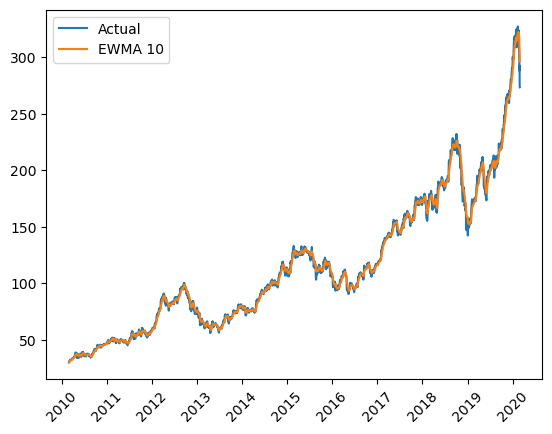

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:\Users\om420\Downloads\archive (7).zip",
    compression='zip',
    skipinitialspace=True
)

# Clean columns
df.columns = df.columns.str.strip()

# Convert types
df['Date'] = pd.to_datetime(df['Date'])
df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)

# Sort data
df = df.sort_values('Date')

# Apply EWMA
df['EWMA_10'] = df['Close/Last'].ewm(span=10).mean()

# Plot
plt.figure()
plt.plot(df['Date'], df['Close/Last'], label='Actual')
plt.plot(df['Date'], df['EWMA_10'], label='EWMA 10')

plt.legend()
plt.xticks(rotation=45)
plt.show()